In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


In [2]:
# ---------- Config ----------
# Path
llm_data_path = '../data/processed_llm.csv'
human_data_path = '../data/processed_human.csv'
output_path = '../visualization'

# Trait
TRAIT_STRUCTURE = {
    'Extraversion':      [1, 6, 11, 16, 21, 26, 31, 36, 41, 46],
    'Agreeableness':     [2, 7, 12, 17, 22, 27, 32, 37, 42, 47],
    'Conscientiousness': [3, 8, 13, 18, 23, 28, 33, 38, 43, 48],
    'Neuroticism':       [4, 9, 14, 19, 24, 29, 34, 39, 44, 49],
    'Openness':          [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
}
REVERSE_ITEMS = {2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28,
                 30, 32, 34, 36, 38, 39, 44, 46, 49}


# Plots
palette = {'Human': '#00c9ac', 'LLM': '#4F2683'}

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'axes.edgecolor':    'black',
    'axes.labelcolor':   'black',
    'axes.titlecolor':   'black',
    'xtick.color':       'black',
    'ytick.color':       'black',
    'text.color':        'black',
    'grid.color':        'black',
    'grid.alpha':        0.3,
    'legend.facecolor':  'white',
    'legend.edgecolor':  'black',
    'legend.labelcolor': 'black',
})

In [3]:
# ---------- Load & preprocess ----------
def load(path):
    df = pd.read_csv(path)
    mapping, k = {}, 1
    for prefix in ['EXT', 'EST', 'AGR', 'CSN', 'OPN']:
        for i in range(1, 11):
            mapping[f'{prefix}{i}'] = f'item_{k}'
            k += 1
    df = df.rename(columns=mapping)
    
    # Reverse score
    for i in REVERSE_ITEMS:
        df[f'item_{i}'] = 6 - df[f'item_{i}']
    return df

human = load(human_data_path)
llm   = load(llm_data_path)

In [4]:
# ---------- Trait scores per respondent ----------
def trait_scores(df):
    return pd.DataFrame({
        t: df[[f'item_{i}' for i in items]].mean(axis=1)
        for t, items in TRAIT_STRUCTURE.items()
    })

human_traits = trait_scores(human)
llm_traits   = trait_scores(llm)

traits = list(TRAIT_STRUCTURE.keys())
human_mean = human_traits.mean().values
human_sd   = human_traits.std().values
llm_mean   = llm_traits.mean().values
llm_sd     = llm_traits.std().values

# Rader plot

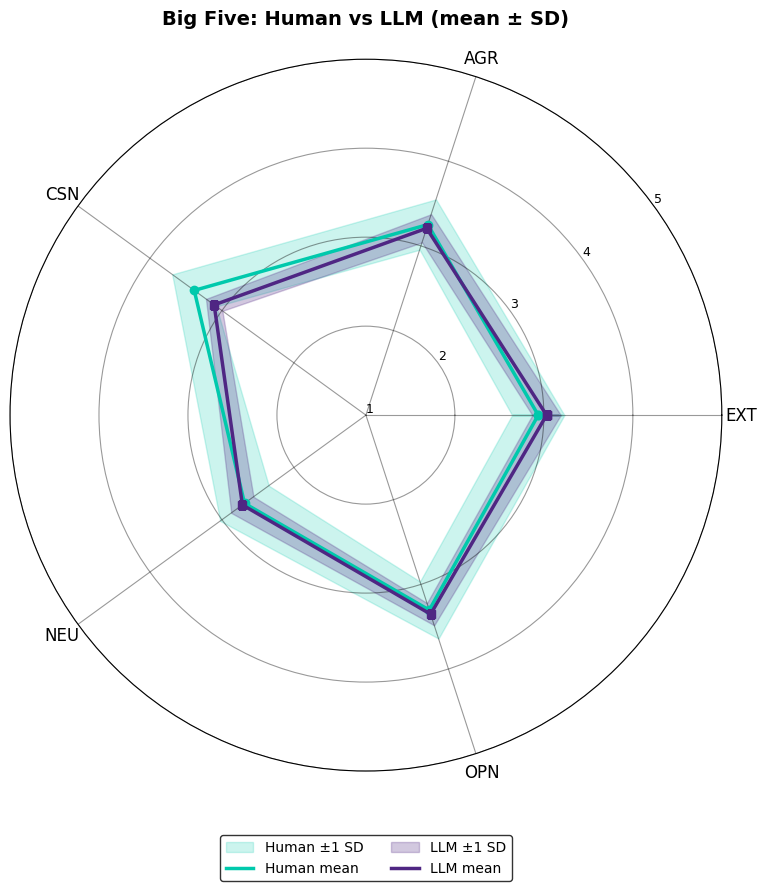

In [9]:
# =====================================================
# PLOT 1: Radar chart with SD bands
# =====================================================
angles = np.linspace(0, 2 * np.pi, len(traits), endpoint=False).tolist()
angles += angles[:1]  # close the loop

def close(vals):
    return np.concatenate([vals, [vals[0]]])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Human band (mean ± SD)
h_m, h_s = close(human_mean), close(human_sd)
ax.fill_between(angles, h_m - h_s, h_m + h_s,
                color=palette['Human'], alpha=0.20, label='Human ±1 SD')
ax.plot(angles, h_m, color=palette['Human'], linewidth=2.5, label='Human mean')
ax.plot(angles, h_m, 'o', color=palette['Human'], markersize=6)

# LLM band (mean ± SD)
l_m, l_s = close(llm_mean), close(llm_sd)
ax.fill_between(angles, l_m - l_s, l_m + l_s,
                color=palette['LLM'], alpha=0.25, label='LLM ±1 SD')
ax.plot(angles, l_m, color=palette['LLM'], linewidth=2.5, label='LLM mean')
ax.plot(angles, l_m, 's', color=palette['LLM'], markersize=6)

TRAIT_ABBREV = {
    'Extraversion':      'EXT',
    'Agreeableness':     'AGR',
    'Conscientiousness': 'CSN',
    'Neuroticism':       'NEU',
    'Openness':          'OPN',
}
abbrev_labels = [TRAIT_ABBREV[t] for t in traits]

ax.set_xticks(angles[:-1])
ax.set_xticklabels(abbrev_labels, fontsize=12)
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=9)
ax.set_rlabel_position(180 / len(traits))
ax.set_title('Big Five: Human vs LLM (mean ± SD)',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=2, fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
import os
plt.savefig(os.path.join(output_path, 'radar_human_vs_llm.png'),
            dpi=300, bbox_inches='tight')
plt.show()

# Distribution per traits

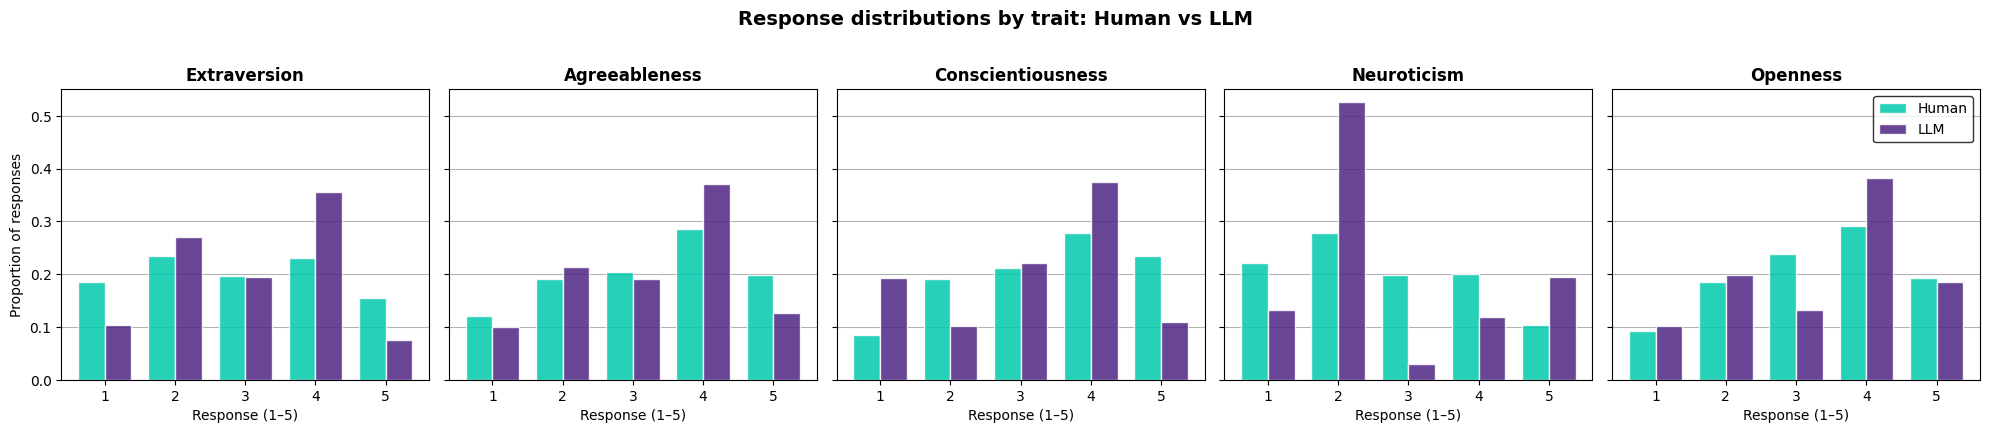

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
categories = [1, 2, 3, 4, 5]
width = 0.38

for ax, trait in zip(axes, traits):
    items = TRAIT_STRUCTURE[trait]
    cols = [f'item_{i}' for i in items]
    # Pool all item responses for this trait → 1–5 distribution
    h_vals = human[cols].values.ravel()
    l_vals = llm[cols].values.ravel()

    h_prop = [np.mean(h_vals == c) for c in categories]
    l_prop = [np.mean(l_vals == c) for c in categories]

    x = np.arange(len(categories))
    ax.bar(x - width/2, h_prop, width, label='Human',
           color=palette['Human'], alpha=0.85, edgecolor='white')
    ax.bar(x + width/2, l_prop, width, label='LLM',
           color=palette['LLM'], alpha=0.85, edgecolor='white')

    ax.set_title(trait, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_xlabel('Response (1–5)')
    ax.set_ylim(0, 0.55)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Proportion of responses')
axes[-1].legend(loc='upper right', fontsize=10)
fig.suptitle('Response distributions by trait: Human vs LLM',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'distributions_human_vs_llm.png'),
            dpi=300, bbox_inches='tight')
plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\%'
<>:50: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2800495/2134832291.py:50: SyntaxWarning: invalid escape sequence '\%'
  fig.suptitle('Response distributions by trait: Human vs LLM (95\% cluster-bootstrap CI)',


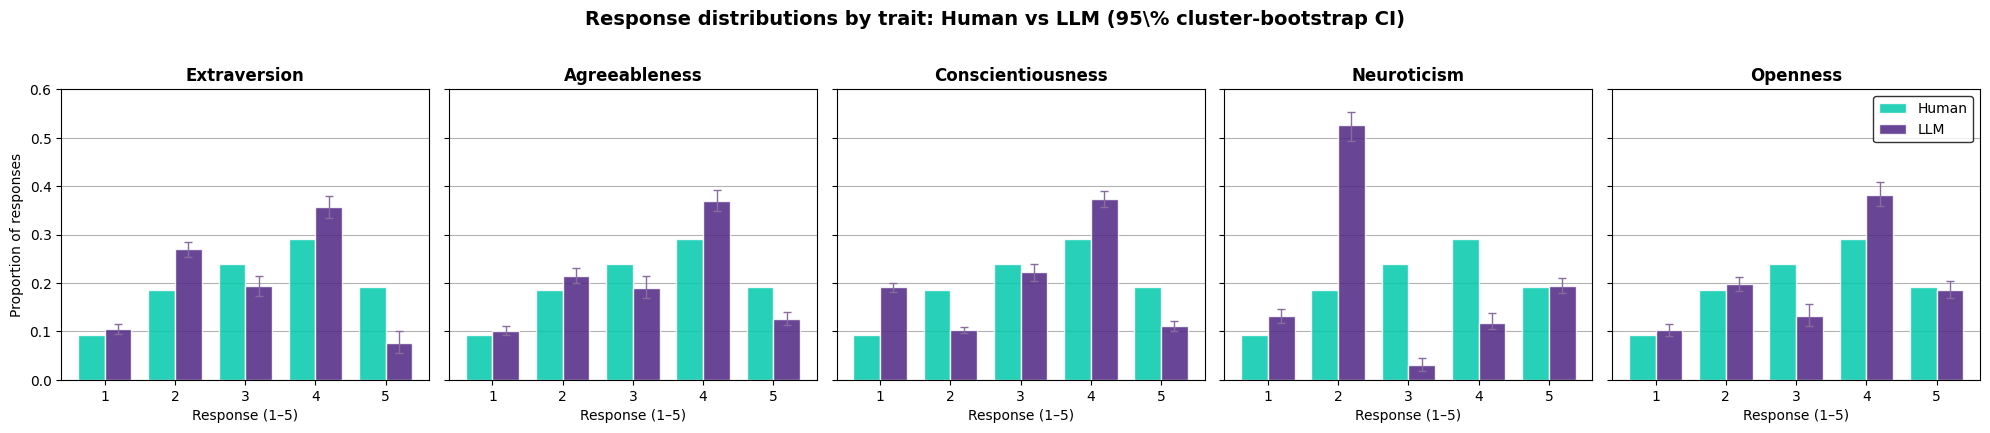

In [17]:
rng = np.random.default_rng(42)
B = 1000  # bootstrap iterations

def cluster_bootstrap_props(df_items, cats, B=1000, rng=None):
    """
    Resample respondents (rows) with replacement, recompute pooled
    item proportions each time. Returns mean proportions and 95% CI half-widths.
    """
    rng = rng or np.random.default_rng()
    arr = df_items.values  # shape: (n_respondents, n_items)
    n = arr.shape[0]
    boot = np.empty((B, len(cats)))
    for b in range(B):
        idx = rng.integers(0, n, size=n)          # resample respondents
        sample = arr[idx].ravel()                  # pool their item responses
        boot[b] = [np.mean(sample == c) for c in cats]
    p = np.array([np.mean(arr.ravel() == c) for c in cats])
    lo = np.percentile(boot, 2.5,  axis=0)
    hi = np.percentile(boot, 97.5, axis=0)
    # asymmetric error bars for ax.bar(yerr=...)
    err = np.vstack([p - lo, hi - p])
    return p, err

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
categories = [1, 2, 3, 4, 5]
width = 0.38

for ax, trait in zip(axes, traits):
    cols = [f'item_{i}' for i in TRAIT_STRUCTURE[trait]]
    # h_prop, h_err = cluster_bootstrap_props(human[cols], categories, B=B, rng=rng)
    l_prop, l_err = cluster_bootstrap_props(llm[cols],   categories, B=B, rng=rng)

    x = np.arange(len(categories))
    ax.bar(x - width/2, h_prop, width, label='Human',
           color=palette['Human'], alpha=0.85, edgecolor='white')
    ax.bar(x + width/2, l_prop, width, yerr=l_err, label='LLM',
           color=palette['LLM'], alpha=0.85, edgecolor='white',
           error_kw=dict(ecolor='#886c9c', lw=1, capsize=3))

    ax.set_title(trait, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_xlabel('Response (1–5)')
    ax.set_ylim(0, 0.6)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Proportion of responses')
axes[-1].legend(loc='upper right', fontsize=10)
fig.suptitle('Response distributions by trait: Human vs LLM (95\% cluster-bootstrap CI)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_path, 'distributions_human_vs_llm_error.png'),
            dpi=300, bbox_inches='tight')
plt.show()

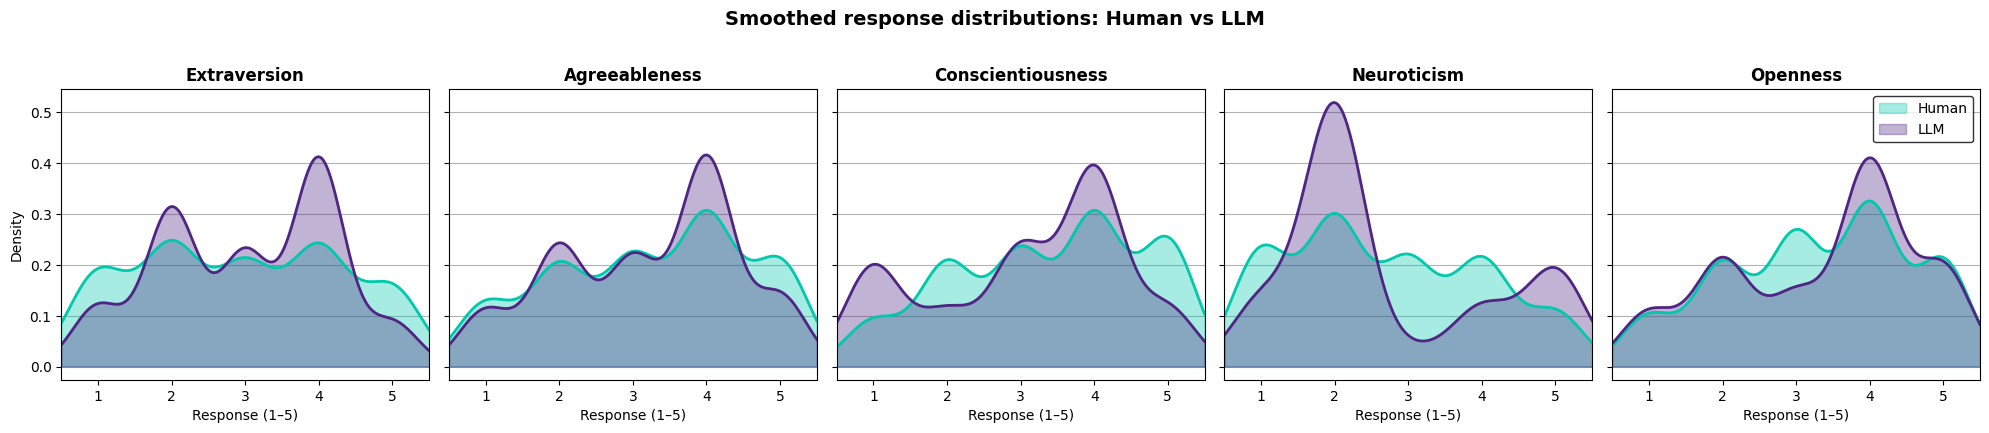

In [7]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
x_grid = np.linspace(0.5, 5.5, 300)

for ax, trait in zip(axes, traits):
    cols = [f'item_{i}' for i in TRAIT_STRUCTURE[trait]]
    h_vals = human[cols].values.ravel()
    l_vals = llm[cols].values.ravel()

    h_kde = gaussian_kde(h_vals, bw_method=0.3)(x_grid)
    l_kde = gaussian_kde(l_vals, bw_method=0.3)(x_grid)

    ax.fill_between(x_grid, h_kde, color=palette['Human'], alpha=0.35, label='Human')
    ax.plot(x_grid, h_kde, color=palette['Human'], linewidth=2)
    ax.fill_between(x_grid, l_kde, color=palette['LLM'], alpha=0.35, label='LLM')
    ax.plot(x_grid, l_kde, color=palette['LLM'], linewidth=2)

    ax.set_title(trait, fontsize=12, fontweight='bold')
    ax.set_xlim(0.5, 5.5)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xlabel('Response (1–5)')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Density')
axes[-1].legend(loc='upper right', fontsize=10)
fig.suptitle('Smoothed response distributions: Human vs LLM',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions_kde.png', dpi=300, bbox_inches='tight')
plt.show()